In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import pandas as pd
import seaborn as sns

In [ ]:
from pandas import read_csv
df=read_csv("datasets\\placement_predict_50k Dataset.csv")

In [ ]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:", list(numerical_features))
print("Categorical Features:", list(categorical_features))

Numerical Features: ['48', '55.7', '0', '1', '0.1', '0.2', '0.3', '61.2', '1.5', '29.7', '29.3', '0.4', '0.5', '0.6', '0.7']
Categorical Features: ['Low']


In [ ]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numerical_cols].corr()

In [ ]:
print("\n--- Correlation Matrix ---")
print(corr_matrix)


--- Correlation Matrix ---
            48      55.7         0         1       0.1       0.2       0.3  \
48    1.000000  0.563180  0.520881  0.578441  0.526397  0.552262  0.448966   
55.7  0.563180  1.000000  0.520278  0.578932  0.612453  0.632673  0.510961   
0     0.520881  0.520278  1.000000  0.637146  0.556039  0.573131  0.480442   
1     0.578441  0.578932  0.637146  1.000000  0.621991  0.654179  0.538021   
0.1   0.526397  0.612453  0.556039  0.621991  1.000000  0.684603  0.558155   
0.2   0.552262  0.632673  0.573131  0.654179  0.684603  1.000000  0.587342   
0.3   0.448966  0.510961  0.480442  0.538021  0.558155  0.587342  1.000000   
61.2  0.634418  0.659013  0.594492  0.674823  0.612128  0.639149  0.515308   
1.5   0.528799  0.609726  0.549770  0.612683  0.645785  0.671158  0.553253   
29.7  0.694939  0.717227  0.650182  0.727843  0.661010  0.692420  0.565984   
29.3  0.605236  0.693596  0.630120  0.707304  0.735314  0.766500  0.624874   
0.4   0.211027  0.242159  0.228842  

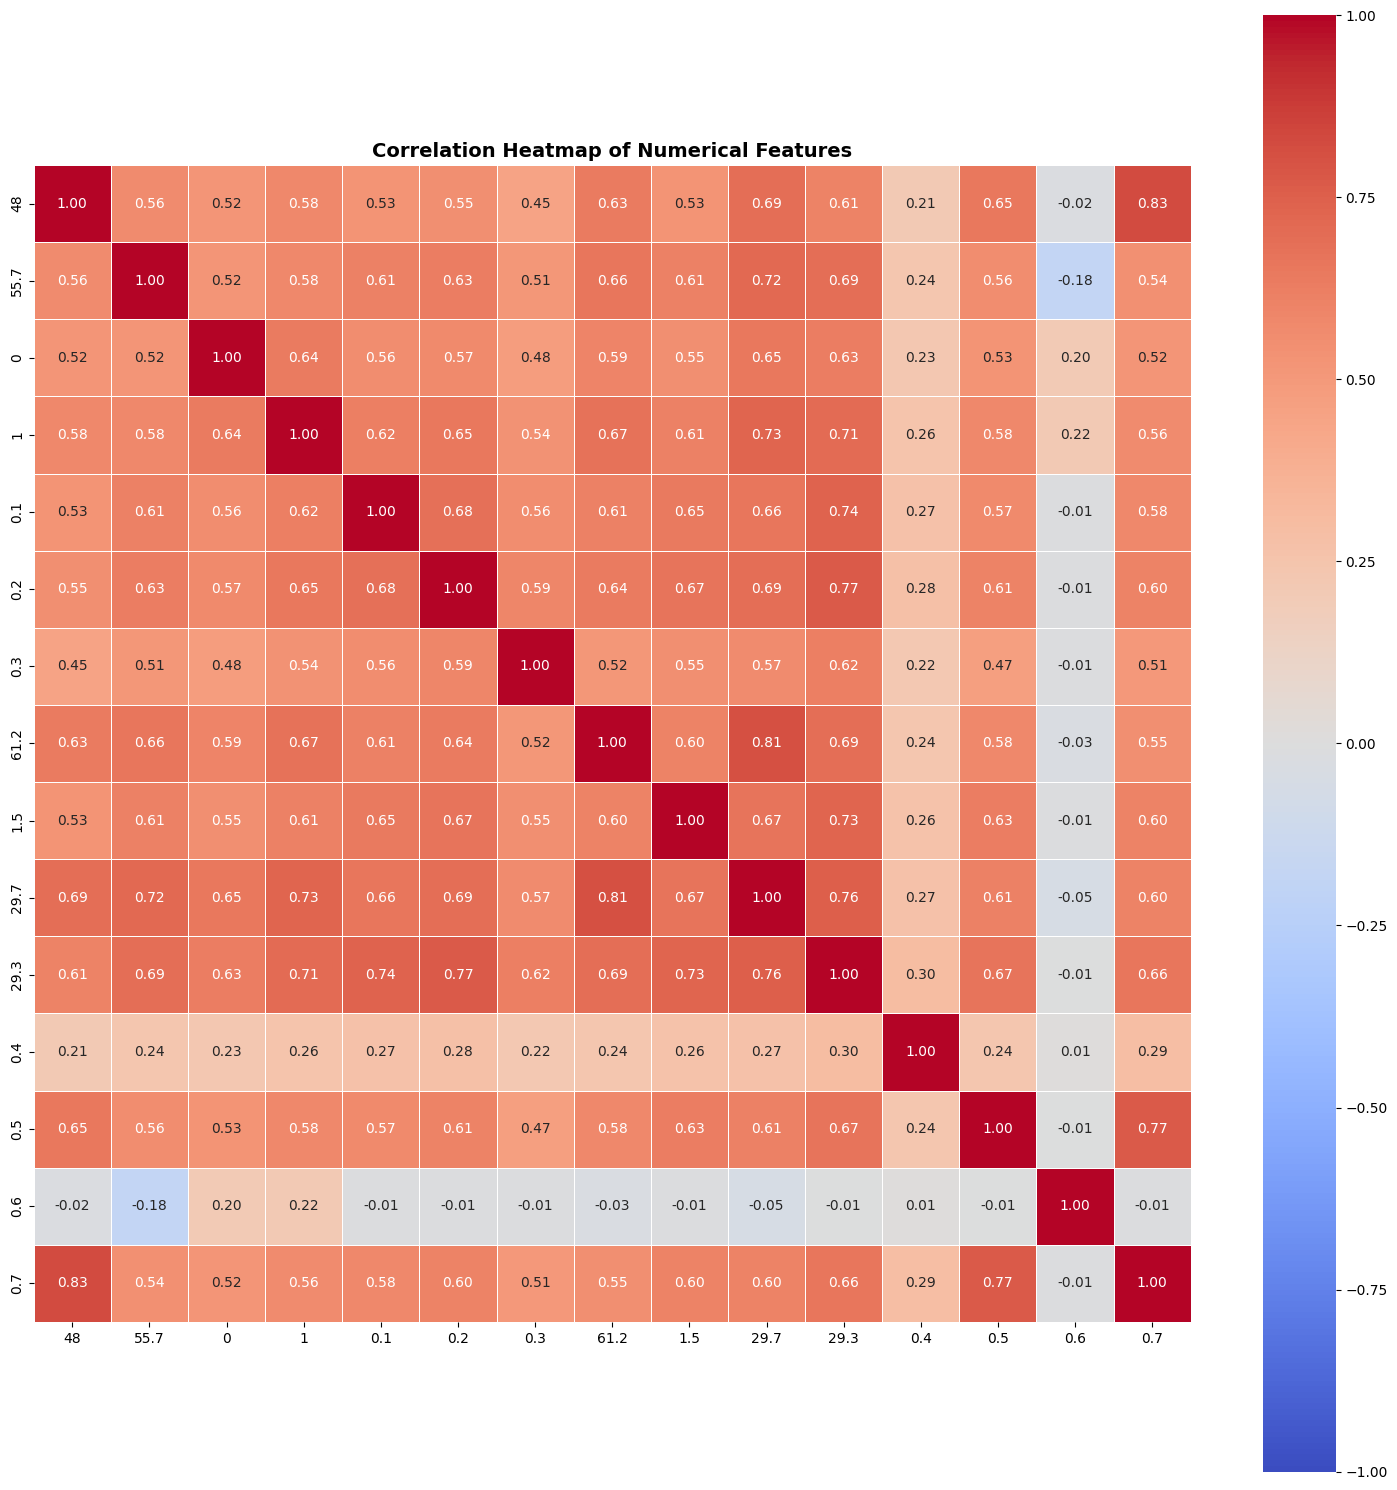

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,15))
sns.heatmap(
corr_matrix,
annot=True,
cmap="coolwarm",
fmt=".2f",
vmin=-1,
vmax=1,
square=True,
linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()

In [ ]:
import os
output_dir = "/content/reports"
os.makedirs(output_dir, exist_ok=True)
heatmap_path = os.path.join(output_dir, "correlation_heatmap.png")
plt.savefig(heatmap_path, dpi=300)
plt.close()
print(f"Exported heatmap to: {heatmap_path}")

Exported heatmap to: /content/reports/correlation_heatmap.png


In [ ]:
target_col = "PlacementStatus"
if target_col in df.columns:
    for col in numerical_cols:
        plt.figure(figsize=(6, 5))
        sns.boxplot(
            x=target_col,
            y=col,
            data=df,
            palette="Set2",
            hue=target_col,
            legend=False
        )
        plt.title(f"{col} vs {target_col}", fontsize=12, fontweight="bold")
        plt.xlabel(target_col)
        plt.ylabel(col)
        plt.tight_layout()
        boxplot_filename = f"boxplot_{col}_vs_{target_col}.png"
        boxplot_path = os.path.join(output_dir, boxplot_filename)
        plt.savefig(boxplot_path,    dpi=300,    bbox_inches="tight")

        plt.close()
        print(f"Exported boxplot to: {boxplot_path}")

    else:
        print(f"\nTarget column '{target_col}' not found in dataset. Skipping boxplots.")

        print("\nAll EDA tasks completed successfully!")



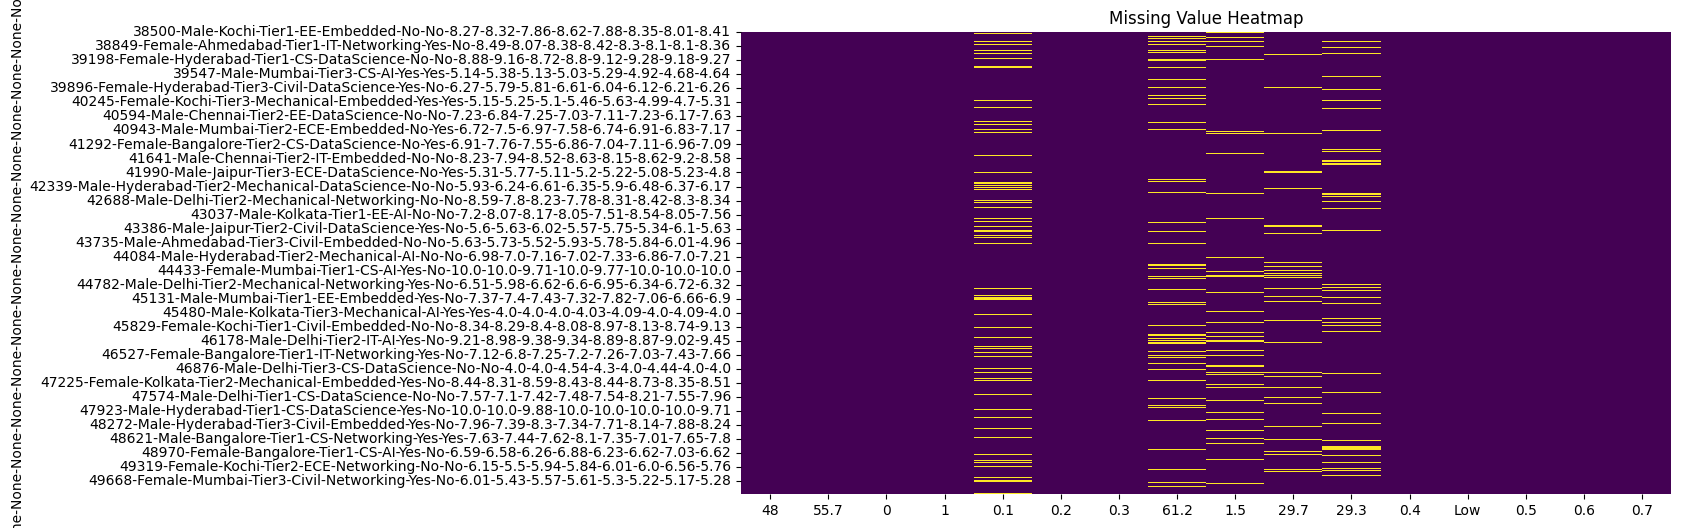

In [ ]:
import matplotlib.pyplot as plt
fig1=plt.figure(figsize=(12,6))

sns.heatmap(
         df.isnull(),
        cbar=False,
         cmap="viridis"
)

plt.title("Missing Value Heatmap")

plt.show()